In [ ]:
# Cell 6 — Live prediction via Track Analysis API
# Prompts for a song name + artist, fetches real audio features, runs the model
import requests

API_KEY  = "72779a9516mshdf850e8303ae898p18c18bjsn2078f1551645"
BASE_URL = "https://track-analysis.p.rapidapi.com/pktx/analysis"

# Prompt user for input
song_name   = input("Enter song name: ")
artist_name = input("Enter artist name (optional, press Enter to skip): ").strip()

params  = {"song": song_name}
if artist_name:
    params["artist"] = artist_name

headers = {
    "x-rapidapi-key" : API_KEY,
    "x-rapidapi-host": "track-analysis.p.rapidapi.com"
}

response = requests.get(BASE_URL, headers=headers, params=params)
response.raise_for_status()
data = response.json()

print(f"\nRaw API response: {data}")

# Transform API values to match model's expected format
# API returns 0-100 for most features; model expects 0-1
# API 'happiness' maps to model's 'valence'
# API 'loudness' is a string like "-5 dB"
features_live = {
    'danceability'    : data['danceability']     / 100,
    'energy'          : data['energy']           / 100,
    'loudness'        : float(str(data['loudness']).replace(' dB', '').replace('dB', '').strip()),
    'speechiness'     : data['speechiness']      / 100,
    'acousticness'    : data['acousticness']     / 100,
    'instrumentalness': data['instrumentalness'] / 100,
    'liveness'        : data['liveness']         / 100,
    'valence'         : data['happiness']        / 100,
    'tempo'           : data['tempo'],
}

# Scale and predict
features_arr    = np.array([[features_live[f] for f in AUDIO_FEATURES]])
features_scaled = scaler.transform(features_arr)

pred_class = rf.predict(features_scaled)[0]
pred_genre = le.inverse_transform([pred_class])[0]
pred_proba = rf.predict_proba(features_scaled)[0]

print(f"\nSong            : {song_name}" + (f" — {artist_name}" if artist_name else ""))
print(f"Predicted genre : {pred_genre.upper()}")
print()
print("Top 3 probabilities:")
for idx in np.argsort(pred_proba)[::-1][:3]:
    print(f"  {le.classes_[idx]:<15} {pred_proba[idx]:.1%}")

# 04 — Visualization & Real-World Validation
Vibe Correlation Map (radar chart) showing the audio DNA per genre, plus real-world song prediction.

In [12]:
# Cell 1 — Imports
import numpy as np
import pandas as pd
import joblib
import matplotlib.pyplot as plt

%matplotlib inline

In [13]:
# Cell 2 — Load dataset and filter to 10 genres
TARGET_GENRES = [
    'hip-hop', 'pop', 'rock', 'classical', 'country',
    'electronic', 'r-n-b', 'jazz', 'metal', 'comedy'
]
AUDIO_FEATURES = [
    'danceability', 'energy', 'loudness', 'speechiness',
    'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo'
]

df = pd.read_csv("../Data/SpotifySongs.csv")
df = df[df['track_genre'].isin(TARGET_GENRES)][AUDIO_FEATURES + ['track_genre']].copy()
print(f"Loaded {len(df):,} tracks across {df['track_genre'].nunique()} genres")

Loaded 10,000 tracks across 10 genres


In [14]:
# Cell 3 — Normalize features to 0-1 scale and compute mean per genre
# loudness (dB) and tempo (BPM) need scaling; all others are already 0-1
df_norm = df.copy()
for col in ['loudness', 'tempo']:
    df_norm[col] = (df[col] - df[col].min()) / (df[col].max() - df[col].min())

audio_dna = df_norm.groupby('track_genre')[AUDIO_FEATURES].mean()
print(audio_dna.round(3))

             danceability  energy  loudness  speechiness  acousticness  \
track_genre                                                              
classical           0.382   0.190     0.503        0.051         0.920   
comedy              0.577   0.700     0.730        0.756         0.726   
country             0.555   0.597     0.805        0.042         0.321   
electronic          0.653   0.695     0.808        0.082         0.177   
hip-hop             0.736   0.683     0.835        0.130         0.194   
jazz                0.510   0.353     0.704        0.055         0.716   
metal               0.464   0.840     0.848        0.070         0.037   
pop                 0.630   0.606     0.813        0.080         0.344   
r-n-b               0.614   0.638     0.799        0.089         0.371   
rock                0.544   0.679     0.819        0.050         0.209   

             instrumentalness  liveness  valence  tempo  
track_genre                                          

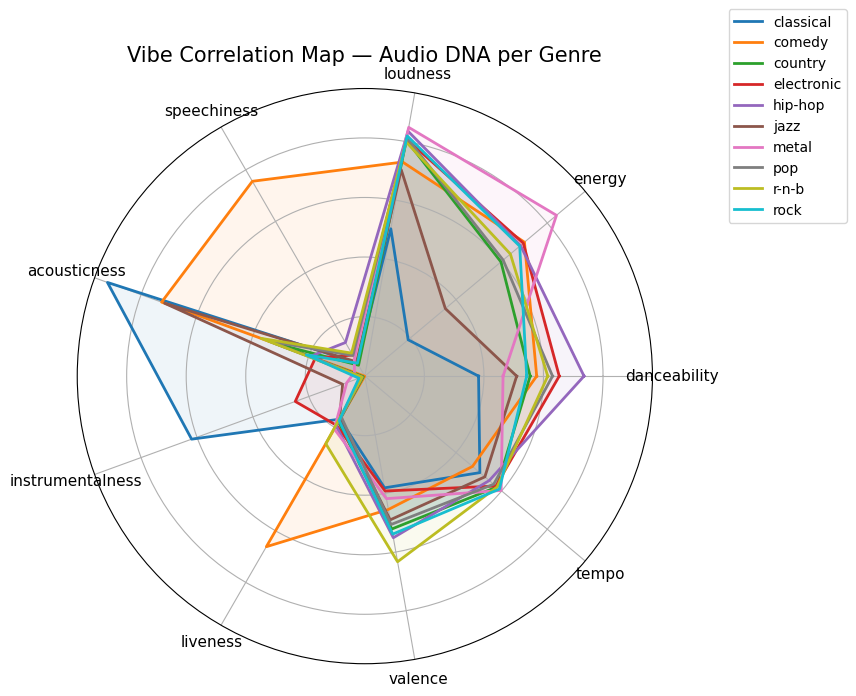

In [15]:
# Cell 4 — Vibe Correlation Map: radar/spider chart
N = len(AUDIO_FEATURES)
angles = np.linspace(0, 2 * np.pi, N, endpoint=False).tolist()
angles += angles[:1]  # close the polygon

fig, ax = plt.subplots(figsize=(9, 9), subplot_kw=dict(polar=True))
colors = plt.cm.tab10(np.linspace(0, 1, len(TARGET_GENRES)))

for genre, color in zip(sorted(TARGET_GENRES), colors):
    if genre not in audio_dna.index:
        continue
    values = audio_dna.loc[genre].tolist()
    values += values[:1]  # close the polygon
    ax.plot(angles, values, linewidth=2, label=genre, color=color)
    ax.fill(angles, values, alpha=0.07, color=color)

ax.set_xticks(angles[:-1])
ax.set_xticklabels(AUDIO_FEATURES, fontsize=11)
ax.set_yticklabels([])
ax.set_title("Vibe Correlation Map — Audio DNA per Genre", fontsize=15, pad=20)
ax.legend(loc='upper right', bbox_to_anchor=(1.35, 1.15), fontsize=10)

plt.tight_layout()
plt.show()

In [16]:
# Cell 5 — Real-world validation: predict the genre of an unseen song
# Swap in any song's audio features to test the model.
# You can look up features at tunebat.com or via the Spotify Web API.

song = {
    'name'            : 'Choosin Texas Ella Langely',
    'danceability'    : 0.68,
    'energy'          : 0.78,
    'loudness'        : -5,
    'speechiness'     : .03,
    'acousticness'    : 0.01,
    'instrumentalness': 0.0,
    'liveness'        : 0.19,
    'valence'         : 0.49,
    'tempo'           : 112,
}

rf     = joblib.load("../models/random_forest.pkl")
le     = joblib.load("../models/label_encoder.pkl")
scaler = joblib.load("../models/scaler.pkl")

features        = np.array([[song[f] for f in AUDIO_FEATURES]])
features_scaled = scaler.transform(features)

pred_class = rf.predict(features_scaled)[0]
pred_genre = le.inverse_transform([pred_class])[0]
pred_proba = rf.predict_proba(features_scaled)[0]

print(f"Song            : {song['name']}")
print(f"Predicted genre : {pred_genre.upper()}")
print()
print("Top 3 probabilities:")
for idx in np.argsort(pred_proba)[::-1][:3]:
    print(f"  {le.classes_[idx]:<15} {pred_proba[idx]:.1%}")

Song            : Choosin Texas Ella Langely
Predicted genre : COUNTRY

Top 3 probabilities:
  country         27.1%
  rock            25.1%
  pop             15.6%


In [17]:
import requests
import numpy as np  # Added missing import

# Configuration
API_KEY  = "72779a9516mshdf850e8303ae898p18c18bjsn2078f1551645"
BASE_URL = "https://track-analysis.p.rapidapi.com/pktx/analysis"

# 1. Prompt user for input
song_name   = input("Enter song name: ")
artist_name = input("Enter artist name (optional, press Enter to skip): ").strip()

params = {"song": song_name}
if artist_name:
    params["artist"] = artist_name # Fixed indentation

headers = {
    "x-rapidapi-key" : API_KEY,
    "x-rapidapi-host": "track-analysis.p.rapidapi.com"
}

# 2. Fetch data from API
try:
    response = requests.get(BASE_URL, headers=headers, params=params)
    response.raise_for_status()
    data = response.json()
    
    print(f"\nRaw API response: {data}")

    # 3. Transform API values to match model's expected format
    # Using .get() and float conversion with error handling for loudness
    features_live = {
        'danceability'    : data.get('danceability', 0)     / 100,
        'energy'          : data.get('energy', 0)           / 100,
        'loudness'        : float(str(data.get('loudness', '0')).replace('dB', '').strip()),
        'speechiness'     : data.get('speechiness', 0)      / 100,
        'acousticness'    : data.get('acousticness', 0)     / 100,
        'instrumentalness': data.get('instrumentalness', 0) / 100,
        'liveness'        : data.get('liveness', 0)         / 100,
        'valence'         : data.get('happiness', 0)        / 100,
        'tempo'           : data.get('tempo', 0),
    }

    # 4. Scale and Predict
    # Ensure AUDIO_FEATURES list is defined (e.g., ['danceability', 'energy', etc.])
    features_arr    = np.array([[features_live[f] for f in AUDIO_FEATURES]])
    features_scaled = scaler.transform(features_arr)

    pred_class = rf.predict(features_scaled)[0]
    pred_genre = le.inverse_transform([pred_class])[0]
    pred_proba = rf.predict_proba(features_scaled)[0]

    # 5. Output Results
    print(f"\nSong            : {song_name}" + (f" — {artist_name}" if artist_name else ""))
    print(f"Predicted genre : {pred_genre.upper()}")
    print("-" * 30)
    print("Top 3 probabilities:")
    
    # Fixed indentation for the sorting loop
    for idx in np.argsort(pred_proba)[::-1][:3]:
        print(f"  {le.classes_[idx]:<15} {pred_proba[idx]:.1%}")

except Exception as e:
    print(f"An error occurred: {e}")


Raw API response: {'id': 'b5cbdb772709121142175d408c3d3658', 'key': 'C#', 'mode': 'major', 'camelot': '3B', 'tempo': 131, 'duration': '4:23', 'popularity': 71, 'energy': 53, 'danceability': 71, 'happiness': 12, 'acousticness': 1, 'instrumentalness': 0, 'liveness': 12, 'speechiness': 3, 'loudness': '-5 dB'}

Song            : Antidote — Travis Scott
Predicted genre : HIP-HOP
------------------------------
Top 3 probabilities:
  hip-hop         24.5%
  pop             21.5%
  country         17.0%
